<a href="https://colab.research.google.com/github/Shambhuraje1919/Machine_Learning_Paractice/blob/main/car_resell_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [305]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tecet1111/cleaned-quikr-used-car-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cleaned-quikr-used-car-dataset' dataset.
Path to dataset files: /kaggle/input/cleaned-quikr-used-car-dataset


In [306]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn
import numpy as np

In [307]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [308]:
os.listdir(path)

['quikr_car_cleaned.csv', 'README.md', 'quikr_car.csv', 'cleaning_report.csv']

In [309]:
df = pd.read_csv(os.path.join(path,"quikr_car.csv"))

In [310]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


In [311]:
df.describe()

,name,company,year,Price,kms_driven,fuel_type
count,892,892,892,892,840,837
unique,525,48,61,274,258,3
top,Honda City,Maruti,2015,Ask For Price,"45,000 kms",Petrol
freq,13,235,117,35,30,440


In [312]:
df.isnull().mean()*100

,0
name,0.000000
company,0.000000
year,0.000000
Price,0.000000
kms_driven,5.829596
fuel_type,6.165919


In [313]:
df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [314]:
df['kms_driven'].unique()

array(['45,000 kms', '40 kms', '22,000 kms', '28,000 kms', '36,000 kms',
       '59,000 kms', '41,000 kms', '25,000 kms', '24,530 kms',
       '60,000 kms', '30,000 kms', '32,000 kms', '48,660 kms',
       '4,000 kms', '16,934 kms', '43,000 kms', '35,550 kms',
       '39,522 kms', '39,000 kms', '55,000 kms', '72,000 kms',
       '15,975 kms', '70,000 kms', '23,452 kms', '35,522 kms',
       '48,508 kms', '15,487 kms', '82,000 kms', '20,000 kms',
       '68,000 kms', '38,000 kms', '27,000 kms', '33,000 kms',
       '46,000 kms', '16,000 kms', '47,000 kms', '35,000 kms',
       '30,874 kms', '15,000 kms', '29,685 kms', '1,30,000 kms',
       '19,000 kms', nan, '54,000 kms', '13,000 kms', '38,200 kms',
       '50,000 kms', '13,500 kms', '3,600 kms', '45,863 kms',
       '60,500 kms', '12,500 kms', '18,000 kms', '13,349 kms',
       '29,000 kms', '44,000 kms', '42,000 kms', '14,000 kms',
       '49,000 kms', '36,200 kms', '51,000 kms', '1,04,000 kms',
       '33,333 kms', '33,600 kms', '5,

In [315]:
df['kms_driven'] = pd.to_numeric(df['kms_driven'].str.replace('kms','',case=False).str.replace(',','',case=False).str.replace('Petrol','').str.strip())

In [316]:
df['kms_driven'].unique()

array([4.50000e+04, 4.00000e+01, 2.20000e+04, 2.80000e+04, 3.60000e+04,
       5.90000e+04, 4.10000e+04, 2.50000e+04, 2.45300e+04, 6.00000e+04,
       3.00000e+04, 3.20000e+04, 4.86600e+04, 4.00000e+03, 1.69340e+04,
       4.30000e+04, 3.55500e+04, 3.95220e+04, 3.90000e+04, 5.50000e+04,
       7.20000e+04, 1.59750e+04, 7.00000e+04, 2.34520e+04, 3.55220e+04,
       4.85080e+04, 1.54870e+04, 8.20000e+04, 2.00000e+04, 6.80000e+04,
       3.80000e+04, 2.70000e+04, 3.30000e+04, 4.60000e+04, 1.60000e+04,
       4.70000e+04, 3.50000e+04, 3.08740e+04, 1.50000e+04, 2.96850e+04,
       1.30000e+05, 1.90000e+04,         nan, 5.40000e+04, 1.30000e+04,
       3.82000e+04, 5.00000e+04, 1.35000e+04, 3.60000e+03, 4.58630e+04,
       6.05000e+04, 1.25000e+04, 1.80000e+04, 1.33490e+04, 2.90000e+04,
       4.40000e+04, 4.20000e+04, 1.40000e+04, 4.90000e+04, 3.62000e+04,
       5.10000e+04, 1.04000e+05, 3.33330e+04, 3.36000e+04, 5.60000e+03,
       7.50000e+03, 2.60000e+04, 2.43300e+04, 6.54800e+04, 2.802

/tmp/ipykernel_3242/2949279586.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sbn.distplot(df['kms_driven'],hist = False)


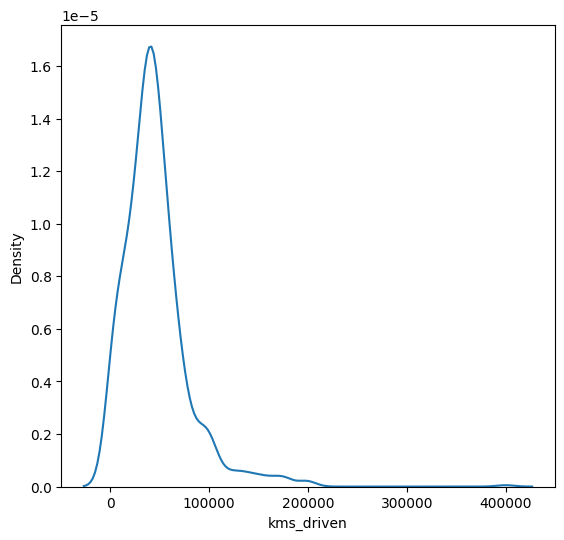

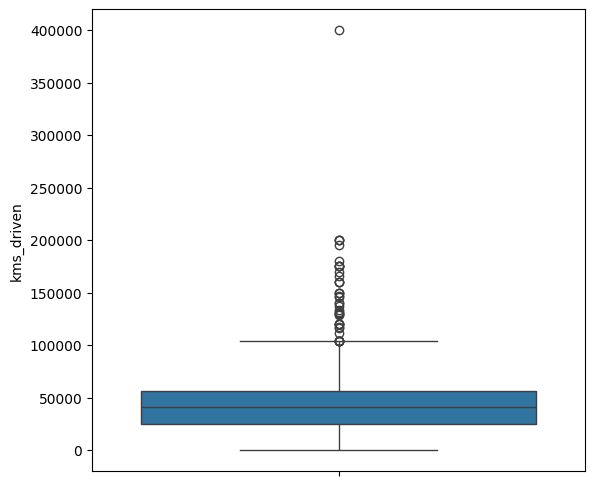

In [317]:
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
sbn.distplot(df['kms_driven'],hist = False)
plt.show()
plt.figure(figsize=(14,6))
plt.subplot(1,2,2)
sbn.boxplot(df['kms_driven'])
plt.show()

In [318]:
df['kms_driven'].describe()

,kms_driven
count,838.000000
mean,46010.550119
std,34469.626299
min,0.000000
25%,25000.000000
50%,41000.000000
75%,56437.500000
max,400000.000000


In [319]:
### outlier Detection and removal thorugh IQR

In [320]:
iq1 = df['kms_driven'].quantile(0.25)
iq3 = df['kms_driven'].quantile(0.75)

In [321]:
print(iq1 ," ", iq3)

25000.0   56437.5


In [322]:
iqr = iq3-iq1

In [323]:
upper = iq3+(1.5*iqr)
lower = iq1-(1.5*iqr)

In [324]:
print(lower , " ", upper)

-22156.25   103593.75


In [325]:
outlier = df[(df['kms_driven']>upper)]

In [326]:
df['kms_driven'] = np.where(df['kms_driven']> upper,upper,
                            np.where(df['kms_driven']<lower,lower,
                                     df['kms_driven']))

<Axes: ylabel='kms_driven'>

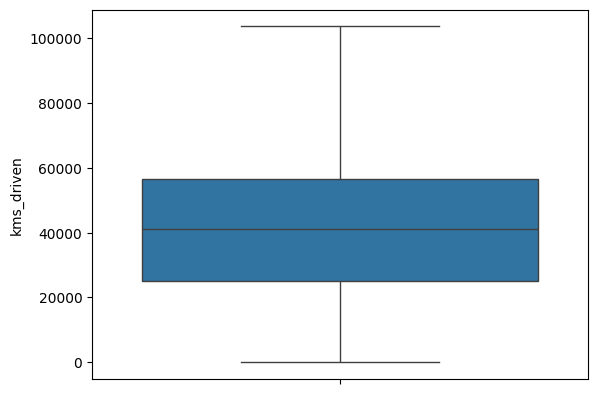

In [327]:
sbn.boxplot(df['kms_driven'])

/tmp/ipykernel_3242/1109430292.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sbn.distplot(df['kms_driven'])


<Axes: xlabel='kms_driven', ylabel='Density'>

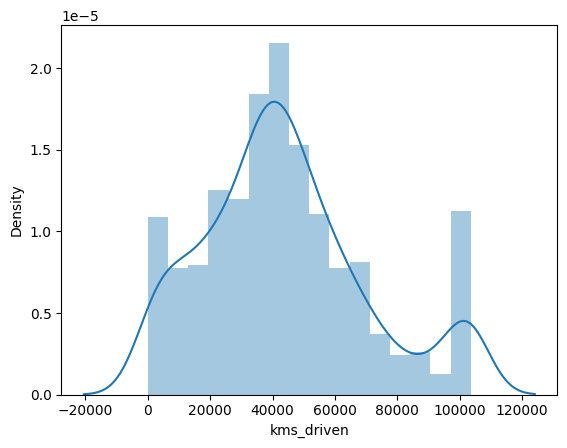

In [328]:
sbn.distplot(df['kms_driven'])

In [329]:
df.isnull().mean()*100

,0
name,0.000000
company,0.000000
year,0.000000
Price,0.000000
kms_driven,6.053812
fuel_type,6.165919


In [330]:
si = SimpleImputer(strategy='mean')
s2 = SimpleImputer(strategy="most_frequent")
df['kms_driven'] = si.fit_transform(df[['kms_driven']])
df['fuel_type'] = s2.fit_transform(df[['fuel_type']]).ravel()

In [331]:
df.isnull().mean()*100

,0
name,0.0
company,0.0
year,0.0
Price,0.0
kms_driven,0.0
fuel_type,0.0


In [332]:

oe = OneHotEncoder(drop='first', sparse_output=False)
fuel_encoded = oe.fit_transform(df[['fuel_type']])
new_col_names = oe.get_feature_names_out(['fuel_type'])
encoded_df = pd.DataFrame(fuel_encoded, columns=new_col_names, index=df.index)
df = pd.concat([df, encoded_df], axis=1).drop(columns=['fuel_type'])

In [333]:
df.head()


,name,company,year,Price,kms_driven,fuel_type_LPG,fuel_type_Petrol
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000",45000.0,0.0,1.0
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40.0,0.0,0.0
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,22000.0,0.0,1.0
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000",28000.0,0.0,1.0
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000",36000.0,0.0,0.0


In [334]:
df.columns

Index(['name', 'company', 'year', 'Price', 'kms_driven', 'fuel_type_LPG',
       'fuel_type_Petrol'],
      dtype='object')

In [335]:
df.isnull().mean()*100

,0
name,0.0
company,0.0
year,0.0
Price,0.0
kms_driven,0.0
fuel_type_LPG,0.0
fuel_type_Petrol,0.0


<Axes: xlabel='Price', ylabel='kms_driven'>

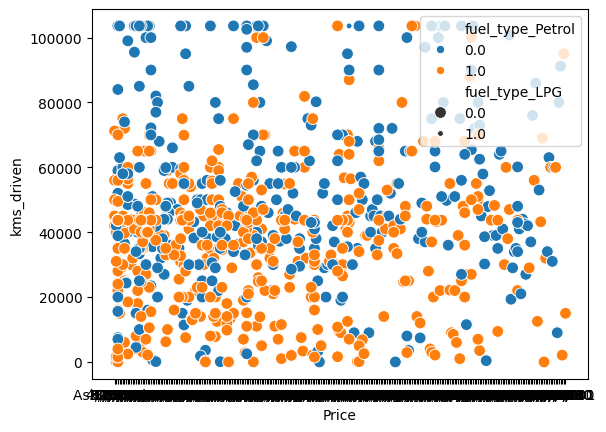

In [336]:
sbn.scatterplot(x =df['Price'],y=df['kms_driven'],hue= df['fuel_type_Petrol'],size=df['fuel_type_LPG'] )

In [337]:
df = df.drop(columns=['name','company'],axis=1)

In [338]:
df.head()

,year,Price,kms_driven,fuel_type_LPG,fuel_type_Petrol
0,2007,"80,000",45000.0,0.0,1.0
1,2006,"4,25,000",40.0,0.0,0.0
2,2018,Ask For Price,22000.0,0.0,1.0
3,2014,"3,25,000",28000.0,0.0,1.0
4,2014,"5,75,000",36000.0,0.0,0.0


In [339]:

df['Price'] = df['Price'].str.replace(',', '')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
mean_price = df['Price'].mean()
df['Price'] = df['Price'].fillna(mean_price).astype(int)

In [340]:
df.head()

,year,Price,kms_driven,fuel_type_LPG,fuel_type_Petrol
0,2007,80000,45000.0,0.0,1.0
1,2006,425000,40.0,0.0,0.0
2,2018,404688,22000.0,0.0,1.0
3,2014,325000,28000.0,0.0,1.0
4,2014,575000,36000.0,0.0,0.0


In [341]:
df.isnull().sum()

,0
year,0
Price,0
kms_driven,0
fuel_type_LPG,0
fuel_type_Petrol,0


In [342]:
df['year'] = pd.to_numeric(df['year'], errors='coerce')
mean = df['year'].mean()
df['year'] = df['year'].fillna(mean).astype(int)

In [343]:
print(df['year'].max())

2019


In [344]:
"""# Calculate how many kms the car travels annually
current_year = 2019
df["car_age"] = current_year - df["year"]

# Avoid division by zero for brand new cars
df["car_age"] = df["car_age"].replace(0, 1)

df["kms_per_year"] = df["kms_driven"] / df["car_age"]"""

'# Calculate how many kms the car travels annually\ncurrent_year = 2019  \ndf["car_age"] = current_year - df["year"]\n\n# Avoid division by zero for brand new cars\ndf["car_age"] = df["car_age"].replace(0, 1)\n\ndf["kms_per_year"] = df["kms_driven"] / df["car_age"]'

In [345]:

# Undo the IQR cap if you can, and try this instead:
#df["kms_driven_log"] = np.log1p(df["kms_driven"])

In [346]:
'''
NUll values are filled
the categorial values are tured into numerical
and the missing values changed with iqr
there are no missing data left '''

'\nNUll values are filled \nthe categorial values are tured into numerical \nand the missing values changed with iqr \nthere are no missing data left '

In [347]:
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [348]:
df.head()

,year,Price,kms_driven,fuel_type_LPG,fuel_type_Petrol
0,2007,80000,45000.0,0.0,1.0
1,2006,425000,40.0,0.0,0.0
2,2018,404688,22000.0,0.0,1.0
3,2014,325000,28000.0,0.0,1.0
4,2014,575000,36000.0,0.0,0.0


In [349]:
x = df.drop('Price',axis=1)

In [350]:
df['year'].unique()

array([2007, 2006, 2018, 2014, 2015, 2012, 2013, 2016, 2010, 2017, 2008,
       2011, 2019, 2009, 2005, 2000, 2003, 2004, 1995, 2002, 2001])

In [351]:
y = df[['Price']]

In [352]:
y.head()

,Price
0,80000
1,425000
2,404688
3,325000
4,575000


In [353]:
x_train , x_test ,y_train ,y_test = train_test_split(x,y,test_size=0.2,random_state=44)

In [354]:
model1 = LinearRegression()

In [355]:
model2 = XGBRegressor(n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,)


In [356]:
model1.fit(x_train,y_train)

LinearRegression()

In [357]:
model2.fit(x_train ,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [358]:
pred1 = model1.predict(x_test)
pred2 = model2.predict(x_test)

In [359]:
r21 = r2_score(y_test, pred1)
mean = mean_absolute_error(y_test,pred1)

In [360]:
r22 = r2_score(y_test,pred2)
mean2 = mean_absolute_error(y_test,pred2)

In [361]:
print(r21 ," " , mean)
print(r22, " ", mean2)

0.1650926664161494   208609.87322576673
0.2900471091270447   191235.953125


In [362]:
print(f"Linear Regression -> MAE: {mean:.2f}, R2 Score: {r21:.2f}")
print(f"XGBoost Regressor -> MAE: {mean2:.2f}, R2 Score: {r22:.2f}")

Linear Regression -> MAE: 208609.87, R2 Score: 0.17
XGBoost Regressor -> MAE: 191235.95, R2 Score: 0.29


In [363]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest
model3 = RandomForestRegressor(n_estimators=75, max_depth=7, random_state=42,min_samples_leaf=17)
model3.fit(x_train, y_train)


pred3 = model3.predict(x_test)

mae3 = mean_absolute_error(y_test, pred3)
r2_3 = r2_score(y_test, pred3)

print(f"Random Forest -> MAE: {mae3:.2f}, R2 Score: {r2_3:.2f}")

Random Forest -> MAE: 197851.15, R2 Score: 0.32


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [364]:
7

7

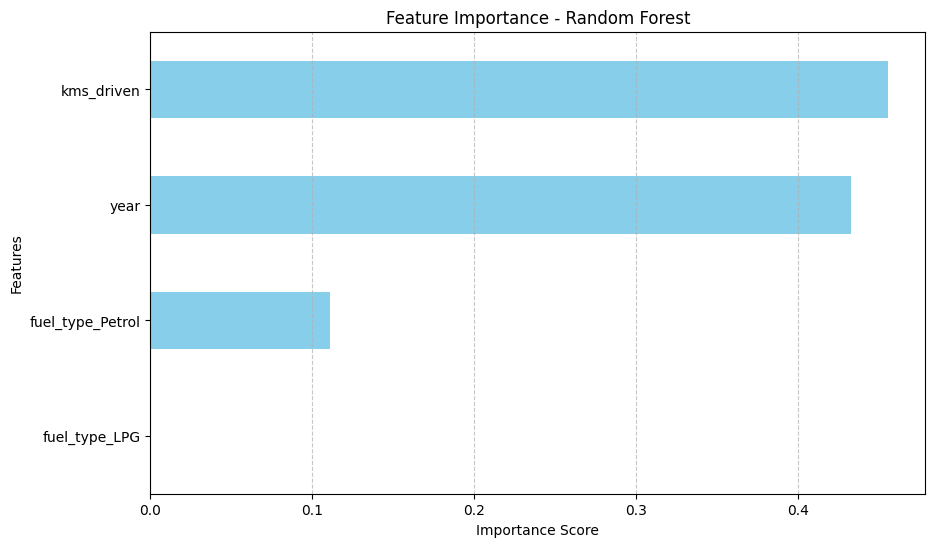

In [365]:

importances = model3.feature_importances_
feature_names = x_train.columns

forest_importances = pd.Series(importances, index=feature_names).sort_values(
    ascending=True
)
plt.figure(figsize=(10, 6))
forest_importances.plot(kind="barh", color="skyblue")
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

In [366]:
print(df["year"].describe())

count     892.000000
mean     2012.494395
std         3.911905
min      1995.000000
25%      2011.000000
50%      2013.000000
75%      2015.000000
max      2019.000000
Name: year, dtype: float64
